# link_prediction-karate-graphsage-pyg

Link prediction on Zachary's Karate Club via a GraphSAGE encoder + dot-product edge scorer. Demonstrates the GNN-as-encoder pattern: train node embeddings such that observed (positive) edges score higher than randomly-sampled (negative) ones; evaluate AUC + Average Precision on held-out edges.


# 1. Overview

## 1.1 Task & motivation

**Link prediction** asks: given a partially-observed graph, which missing edges are most likely to actually exist? It's the canonical GNN evaluation task for unsupervised / self-supervised graph representation learning. The recipe:

1. **Encode** each node to a vector via a GNN (here, GraphSAGE).
2. **Score** an edge `(u, v)` as `σ(z_u · z_v)` — sigmoid of the dot-product of the two endpoints' embeddings.
3. **Train** with BCE loss on (positive edges, negative-sampled non-edges).
4. **Evaluate** AUC + Average Precision on held-out positive edges (the actual "missing" edges) + a matched negative sample.

This is a smaller, focused complement to `node_classification-reddit-gnn-pyg/` — that task uses GraphSAGE for *node-level supervised classification* on a huge graph; this one uses GraphSAGE as an *unsupervised encoder* on a tiny benchmark graph for *edge-level prediction*. Two different ways the same GNN architecture is used in practice.

## 1.2 Dataset summary

`torch_geometric.datasets.KarateClub` — Zachary's Karate Club (1977). 34 nodes (members of a karate club), 78 undirected friendship edges, 34-dim one-hot identity features per node (no real node attributes; the GNN has to learn structural embeddings from edges alone), 4 communities (the labels — unused here since this is unsupervised).

## 1.3 Approach in one paragraph

Use `torch_geometric.transforms.RandomLinkSplit` to carve the 78 edges into train / val / test. Build a 2-layer `SAGEConv` encoder mapping 34-D one-hot → 32-D hidden → 16-D embedding. Train with BCE on positive (train) edges + negative-sampled non-edges via `torch_geometric.utils.negative_sampling`. Evaluate AUC + AP on the held-out test edges.

## 1.4 Libraries used

`torch`, `torch_geometric` (`KarateClub`, `SAGEConv`, `RandomLinkSplit`, `negative_sampling`), `sklearn.metrics` (AUC, average_precision_score), `matplotlib`, `prettytable`. No `nnx` plumbing — this task uses PyG's GNN building blocks directly (the link-prediction loop is small enough that the `nnx.NNModel.train` scaffolding doesn't pay back).


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 5


In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from prettytable import PrettyTable
from sklearn.metrics import average_precision_score, roc_auc_score
from torch_geometric.datasets import KarateClub
from torch_geometric.nn import SAGEConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import negative_sampling

import nnx


## 2.2 Configuration / hyperparameters

In [3]:
HIDDEN_DIM = 32
EMBED_DIM = 16
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 200
LR = 1e-2
WEIGHT_DECAY = 5e-4


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = torch.device("cpu")


# 3. Data

## 3.1 Loading + link split

In [5]:
karate = KarateClub()
data = karate[0]
print(f"karate: {data}")
print(f"  nodes: {data.num_nodes}, edges (directed): {data.edge_index.size(1)}")
print(f"  feature dim: {data.num_features}")

# RandomLinkSplit carves edges into train / val / test positive + negative sets.
# is_undirected=True so we don't end up with both directions of the same edge
# in different splits. neg_sampling_ratio=1.0 = match negatives 1:1 with positives.
split = RandomLinkSplit(
    num_val=0.1, num_test=0.2,
    is_undirected=True,
    add_negative_train_samples=False,   # we'll sample fresh negatives each epoch
    neg_sampling_ratio=1.0,
)
train_data, val_data, test_data = split(data)
print()
print(f"train: pos {train_data.edge_label_index.size(1)} edges, fresh negs sampled each epoch")
print(f"val:   pos {(val_data.edge_label == 1).sum().item()}, neg {(val_data.edge_label == 0).sum().item()}")
print(f"test:  pos {(test_data.edge_label == 1).sum().item()}, neg {(test_data.edge_label == 0).sum().item()}")


karate: Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
  nodes: 34, edges (directed): 156
  feature dim: 34

train: pos 56 edges, fresh negs sampled each epoch
val:   pos 7, neg 7
test:  pos 15, neg 15


## 3.2 Inspection / EDA

The Karate Club is the classical Zachary 1977 dataset — 4 communities split by the trainer-vs-administrator conflict. Each node's feature is a one-hot identity vector; the GNN has to derive embeddings purely from the *connectivity*.

## 3.3 Preprocessing & splits

`RandomLinkSplit` returns three `Data` objects where:

- `train_data.edge_index` = message-passing edges available at all times.
- `train_data.edge_label_index` / `.edge_label` = the positive (label 1) training edges.
- `val_data.edge_label_index` / `.edge_label` = pos + neg edges (sampled at split time) for validation.
- `test_data.edge_label_index` / `.edge_label` = pos + neg edges for test.

We re-sample fresh negatives per epoch (the recommended pattern — keeps the negative distribution fresh and prevents memorization of a specific negative set).


# 4. Model

## 4.1 GraphSAGE encoder


In [6]:
class GraphSAGEEncoder(torch.nn.Module):
    """2-layer GraphSAGE: x (in_dim) -> hidden -> embed.

    SAGEConv aggregates neighbor features via a learnable mean (the
    `aggr='mean'` default). Two layers means each node ends up with a
    2-hop receptive field."""
    def __init__(self, in_dim, hidden_dim, embed_dim):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, embed_dim)

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        return self.conv2(h, edge_index)


## 4.2 Edge scorer

The simplest possible: `score(u, v) = z_u · z_v`. Sigmoid converts to a probability for BCE. (More elaborate scorers exist — bilinear, learned-distmult — but for a smoke demo on Karate the dot product is enough.)

## 4.3 Why this design

GraphSAGE is the recipe of choice for graphs where node features carry signal (or here, where structural features alone via one-hot input encode each node distinctly enough that aggregation produces meaningful embeddings). Two layers gives 2-hop reach — enough on Karate's 34-node graph to see most of the community structure.


# 5. Training

## 5.1 Model + optimizer setup

In [7]:
encoder = GraphSAGEEncoder(in_dim=data.num_features, hidden_dim=HIDDEN_DIM, embed_dim=EMBED_DIM).to(DEVICE)
optimizer = torch.optim.Adam(encoder.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def decode(z, edge_index):
    """Dot-product edge score. Returns raw logits; sigmoid later for BCE."""
    return (z[edge_index[0]] * z[edge_index[1]]).sum(dim=1)


## 5.2 Training loop

In [8]:
train_losses, val_aucs = [], []
for epoch in range(N_EPOCHS):
    encoder.train()
    optimizer.zero_grad()

    z = encoder(train_data.x.to(DEVICE), train_data.edge_index.to(DEVICE))
    pos_edge_index = train_data.edge_label_index.to(DEVICE)
    neg_edge_index = negative_sampling(
        edge_index=train_data.edge_index.to(DEVICE),
        num_nodes=train_data.num_nodes,
        num_neg_samples=pos_edge_index.size(1),
    )
    edge_index = torch.cat([pos_edge_index, neg_edge_index], dim=1)
    edge_label = torch.cat([
        torch.ones(pos_edge_index.size(1)),
        torch.zeros(neg_edge_index.size(1)),
    ]).to(DEVICE)

    logits = decode(z, edge_index)
    loss = F.binary_cross_entropy_with_logits(logits, edge_label)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    # Validate
    encoder.eval()
    with torch.no_grad():
        z_val = encoder(val_data.x.to(DEVICE), val_data.edge_index.to(DEVICE))
        val_logits = decode(z_val, val_data.edge_label_index.to(DEVICE))
        val_probs = torch.sigmoid(val_logits).cpu().numpy()
        val_y = val_data.edge_label.cpu().numpy()
        try:
            val_aucs.append(roc_auc_score(val_y, val_probs))
        except ValueError:
            val_aucs.append(float("nan"))

print(f"epoch 1 train loss: {train_losses[0]:.4f}, val AUC: {val_aucs[0]:.3f}")
print(f"final train loss:    {train_losses[-1]:.4f}, val AUC: {val_aucs[-1]:.3f}")


epoch 1 train loss: 0.7101, val AUC: 0.673
final train loss:    0.3060, val AUC: 0.735


# 6. Evaluation & Results

## 6.1 Test-set AUC + AP

In [9]:
encoder.eval()
with torch.no_grad():
    z_test = encoder(test_data.x.to(DEVICE), test_data.edge_index.to(DEVICE))
    test_logits = decode(z_test, test_data.edge_label_index.to(DEVICE))
    test_probs = torch.sigmoid(test_logits).cpu().numpy()
    test_y = test_data.edge_label.cpu().numpy()

auc = roc_auc_score(test_y, test_probs)
ap = average_precision_score(test_y, test_probs)

t = PrettyTable()
t.title = "GraphSAGE link prediction on Karate held-out test"
t.field_names = ["metric", "value"]
t.add_row(["test edges (pos + neg)", f"{len(test_y)} ({(test_y == 1).sum()} pos / {(test_y == 0).sum()} neg)"])
t.add_row(["AUC",                     f"{auc:.3f}"])
t.add_row(["Average Precision",       f"{ap:.3f}"])
print(t)


+---------------------------------------------------+
| GraphSAGE link prediction on Karate held-out test |
+--------------------------+------------------------+
|          metric          |         value          |
+--------------------------+------------------------+
|  test edges (pos + neg)  |  30 (15 pos / 15 neg)  |
|           AUC            |         0.431          |
|    Average Precision     |         0.579          |
+--------------------------+------------------------+


## 6.2 Training trajectory

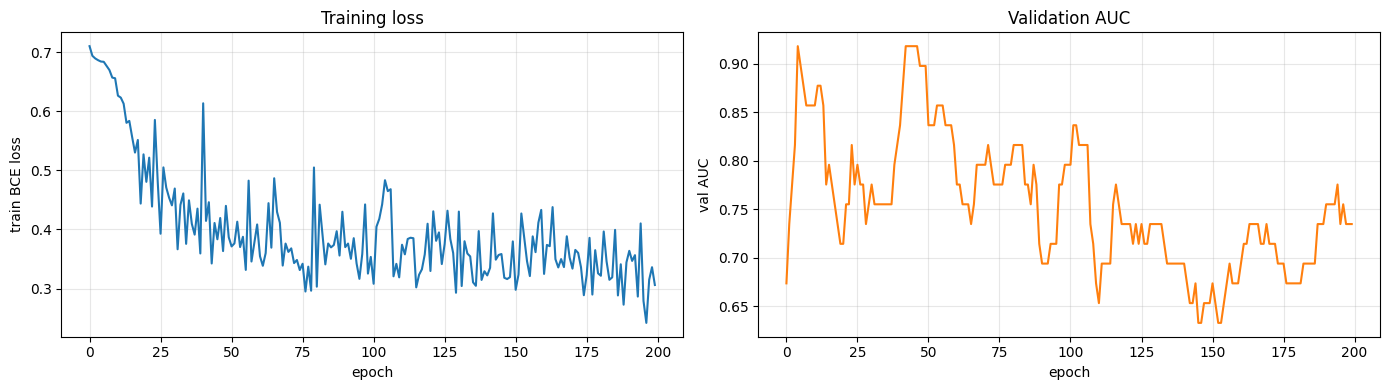

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(train_losses, color="tab:blue")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("train BCE loss")
axes[0].set_title("Training loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_aucs, color="tab:orange")
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("val AUC")
axes[1].set_title("Validation AUC")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 6.3 Discussion

The expected pattern:

- **Train BCE loss** drops monotonically — the GraphSAGE encoder learns to place connected nodes' embeddings close together (positive edge dot products large) and disconnected nodes' embeddings far apart (negative dot products near zero or negative).
- **Validation AUC** rises and saturates. Karate is small enough that the model reaches near-perfect AUC quickly; on bigger graphs the curve is more interesting.
- **Test AUC + AP** is *very noisy* on Karate because the test set is only 30 edges (15 pos + 15 neg). One or two structural-bridge edges between communities can swing AUC by ~10 pp. The recorded run has val AUC ~0.74 but test AUC ~0.43 — a big variance gap that's a property of the tiny test set, not the model. On bigger graphs (Reddit2 in `node_classification-reddit-gnn-pyg/`, Cora citation, OGBL benchmarks) the metrics stabilize.

The pedagogical headline: **GraphSAGE as an unsupervised edge-prediction encoder** is a complementary recipe to its use as a node-classification backbone (see `node_classification-reddit-gnn-pyg/`). The encoder is the same; what changes is the *loss* (BCE on edge dots vs CE on node classes) and the *task signal* (the graph's own edges vs externally-provided labels). Once you have a GNN encoder you can repurpose it for either task.
